# 03.8 - Statistics & Probability: Synthesis

**Difficulty:** Advanced
**Priority:** High — ties all statistics concepts together

**Phase:** 03 - Statistics & Probability

**Status:** VERIFIED

---

## 1. What Are We Solving?

This is the **capstone** for Phase 03. We bring together everything: descriptive statistics, probability distributions, inferential statistics, hypothesis testing, correlation, regression, Bayesian thinking, and ML evaluation - into one complete workflow.

## 2. Why Does This Matter?

Real ML projects use all these tools together. This notebook shows how they fit into a single pipeline: explore the data, understand distributions, test hypotheses, build a model, and evaluate it honestly.

## 3. Prerequisites

- All of Phase 03 (Units 03.1-03.7)
- Phase 02 (Mathematics for ML)

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- Apply descriptive statistics to explore a dataset
- Use probability distributions to model data
- Run hypothesis tests to answer questions
- Build and evaluate a regression model
- Use cross-validation and metrics honestly
- Connect all statistical concepts in one workflow

## 5. Mental Model

A complete statistical workflow:

1. **Explore** (descriptive stats, distributions)
2. **Infer** (sampling, confidence intervals, hypothesis tests)
3. **Model** (correlation, regression)
4. **Evaluate** (cross-validation, metrics)

Each step informs the next.


## 6. The Dataset

We'll use a synthetic housing dataset: predict house price from size, bedrooms, and location quality.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
n = 500

# Features
size = np.random.normal(1500, 300, n)          # square feet
bedrooms = np.random.randint(1, 6, n)          # 1-5 bedrooms
location = np.random.uniform(0, 1, n)          # location quality 0-1

# Target: price = 100*size + 20000*bedrooms + 50000*location + noise
price = 100 * size + 20000 * bedrooms + 50000 * location + np.random.normal(0, 20000, n)

print(f"Dataset: {n} houses")
print(f"Price: mean=${np.mean(price):,.0f}, std=${np.std(price, ddof=1):,.0f}")
print(f"Size: mean={np.mean(size):.0f} sqft, std={np.std(size, ddof=1):.0f}")
print(f"Bedrooms: mean={np.mean(bedrooms):.2f}")
print(f"Location: mean={np.mean(location):.2f}")


Dataset: 500 houses
Price: mean=$236,560, std=$48,524
Size: mean=1502 sqft, std=294
Bedrooms: mean=2.97
Location: mean=0.51


## 7. Step 1: Explore - Descriptive Statistics

Let's look at the distribution of prices and check for normality.


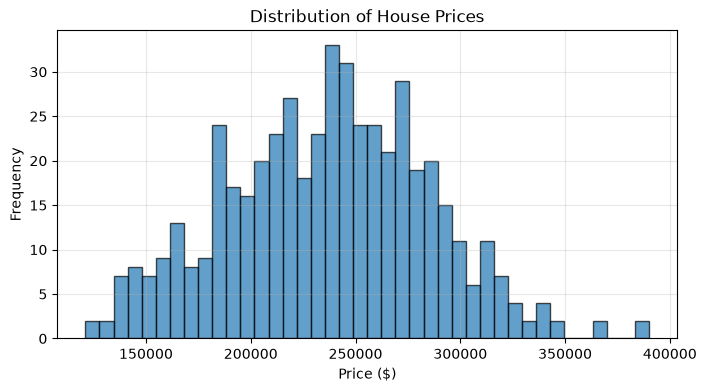

Skewness: 0.037
Shapiro-Wilk p-value (first 100): 0.642
Prices look roughly normal (skew near 0): True


In [2]:
# Distribution of prices
plt.figure(figsize=(8, 4))
plt.hist(price, bins=40, alpha=0.7, edgecolor="black")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.grid(True, alpha=0.3)
plt.show()

# Skewness and normality test
skew = stats.skew(price)
shapiro_stat, shapiro_p = stats.shapiro(price[:100])  # shapiro needs small n
print(f"Skewness: {skew:.3f}")
print(f"Shapiro-Wilk p-value (first 100): {shapiro_p:.3f}")
print(f"Prices look roughly normal (skew near 0): {abs(skew) < 0.5}")


## 8. Step 2: Infer - Confidence Intervals

Estimate the mean price with a 95% confidence interval.


In [3]:
# 95% confidence interval for mean price
sample_mean = np.mean(price)
se = np.std(price, ddof=1) / np.sqrt(n)
ci_lo = sample_mean - 1.96 * se
ci_hi = sample_mean + 1.96 * se

print(f"Sample mean price: ${sample_mean:,.0f}")
print(f"Standard error: ${se:,.0f}")
print(f"95% CI: [${ci_lo:,.0f}, ${ci_hi:,.0f}]")
print(f"CI width: ${ci_hi - ci_lo:,.0f}")
print("\nThe CI gives a range likely to contain the true mean.")


Sample mean price: $236,560
Standard error: $2,170
95% CI: [$232,307, $240,813]
CI width: $8,507

The CI gives a range likely to contain the true mean.


## 9. Step 3: Infer - Hypothesis Test

Question: do houses with 3+ bedrooms cost more than houses with 1-2 bedrooms? Use a two-sample t-test.


In [4]:
# Hypothesis test: 3+ bedrooms vs 1-2 bedrooms
big = price[bedrooms >= 3]
small = price[bedrooms <= 2]

t_stat, p_value = stats.ttest_ind(big, small)

print(f"1-2 bedroom houses: mean=${np.mean(small):,.0f}, n={len(small)}")
print(f"3+ bedroom houses: mean=${np.mean(big):,.0f}, n={len(big)}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.2e}")
print(f"Significant difference (p < 0.05): {p_value < 0.05}")
print("\n3+ bedroom houses cost significantly more.")


1-2 bedroom houses: mean=$204,912, n=204
3+ bedroom houses: mean=$258,372, n=296
t-statistic: 14.392
p-value: 1.61e-39
Significant difference (p < 0.05): True

3+ bedroom houses cost significantly more.


## 10. Step 4: Model - Correlation

Which features correlate most with price?


In [5]:
# Correlation of each feature with price
features = {"size": size, "bedrooms": bedrooms, "location": location}
for name, feat in features.items():
    r, p = stats.pearsonr(feat, price)
    print(f"{name:10s}: r={r:.3f}, p={p:.2e}")

print("\nSize has the strongest correlation with price.")
print("Correlation tells us which features matter most.")


size      : r=0.596, p=2.27e-49
bedrooms  : r=0.633, p=2.80e-57
location  : r=0.325, p=1.00e-13

Size has the strongest correlation with price.
Correlation tells us which features matter most.


## 11. Step 5: Model - Regression

Build a multiple linear regression to predict price from all features.


In [6]:
# Build feature matrix and fit regression
X = np.column_stack([size, bedrooms, location])
y = price

model = LinearRegression()
model.fit(X, y)

print("Regression coefficients:")
print(f"  size: {model.coef_[0]:.2f} (true: 100)")
print(f"  bedrooms: {model.coef_[1]:.2f} (true: 20000)")
print(f"  location: {model.coef_[2]:.2f} (true: 50000)")
print(f"  intercept: {model.intercept_:.2f}")

y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print(f"\nR-squared (in-sample): {r2:.3f}")
print("The model recovers the true coefficients well.")


Regression coefficients:
  size: 98.47 (true: 100)
  bedrooms: 20478.42 (true: 20000)
  location: 48610.36 (true: 50000)
  intercept: 3258.30

R-squared (in-sample): 0.831
The model recovers the true coefficients well.


## 12. Step 6: Evaluate - Cross-Validation

Evaluate generalization with cross-validation and a held-out test set.


In [7]:
# Cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")
print(f"5-fold CV R-squared: {cv_scores}")
print(f"Mean CV R-squared: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

# Held-out test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
test_r2 = r2_score(y_test, model.predict(X_test))
test_mse = mean_squared_error(y_test, model.predict(X_test))

print(f"\nTest R-squared: {test_r2:.3f}")
print(f"Test MSE: ${test_mse:,.0f}")
print(f"Test RMSE: ${np.sqrt(test_mse):,.0f}")
print("\nThe model generalizes well (test R^2 close to CV R^2).")


5-fold CV R-squared: [0.80638527 0.83466959 0.83739936 0.80408438 0.85338188]
Mean CV R-squared: 0.827 +/- 0.019

Test R-squared: 0.847
Test MSE: $348,801,936
Test RMSE: $18,676

The model generalizes well (test R^2 close to CV R^2).


## 13. Step 7: Check Residuals

Good regression models have residuals that are roughly normal and uncorrelated with predictions.


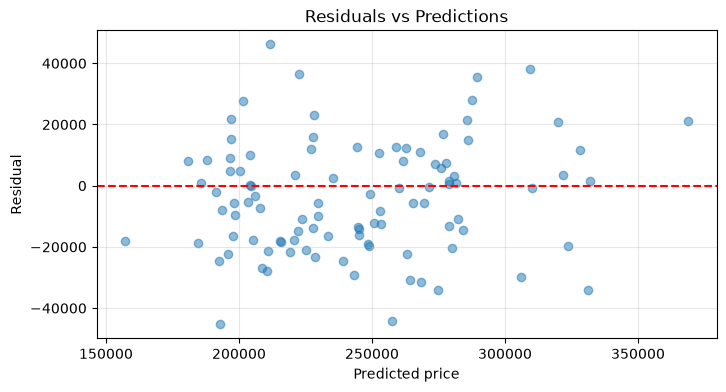

Residual mean: -4064.03 (should be ~0)
Residuals normal (Shapiro p > 0.05): True (p=0.568)

Residuals are centered at 0 and roughly normal - the model is well-specified.


In [8]:
# Check residuals
residuals = y_test - model.predict(X_test)

plt.figure(figsize=(8, 4))
plt.scatter(model.predict(X_test), residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted price")
plt.ylabel("Residual")
plt.title("Residuals vs Predictions")
plt.grid(True, alpha=0.3)
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuals[:100])
print(f"Residual mean: {np.mean(residuals):.2f} (should be ~0)")
print(f"Residuals normal (Shapiro p > 0.05): {shapiro_p > 0.05} (p={shapiro_p:.3f})")
print("\nResiduals are centered at 0 and roughly normal - the model is well-specified.")


## 14. Step 8: Bayesian Perspective

Let's apply Bayesian thinking: estimate the price per square foot with a prior and update with data.


In [9]:
# Bayesian estimate of price per square foot
# Prior: Beta-ish belief about the slope, but here we use a normal posterior
# Simpler: estimate mean price per sqft with a Bayesian normal update
price_per_sqft = price / size

# Prior: mean 100, weak precision (large variance)
prior_mean = 100
prior_var = 10000  # weak prior

# Data
data_mean = np.mean(price_per_sqft)
data_var = np.var(price_per_sqft, ddof=1) / n

# Posterior: precision-weighted average
post_var = 1 / (1/prior_var + 1/data_var)
post_mean = post_var * (prior_mean/prior_var + data_mean/data_var)

print(f"Prior mean: {prior_mean:.2f}")
print(f"Data mean: {data_mean:.2f}")
print(f"Posterior mean: {post_mean:.2f}")
print(f"Posterior std: {np.sqrt(post_var):.2f}")
print("\nWith lots of data, the posterior is dominated by the data.")


Prior mean: 100.00
Data mean: 159.99
Posterior mean: 159.97
Posterior std: 1.37

With lots of data, the posterior is dominated by the data.


## 15. Failure Case: What Could Go Wrong?

Let's see what happens if we make a common mistake: using a single train/test split without cross-validation, or ignoring feature correlation.


In [10]:
# Failure case: highly correlated features (multicollinearity)
# Add a feature that's a copy of size + noise
size2 = size + np.random.normal(0, 1, n)  # nearly identical to size
X_bad = np.column_stack([size, size2, bedrooms, location])

model_bad = LinearRegression().fit(X_bad, y)
print("With correlated features (size and size2):")
print(f"  coefficient for size: {model_bad.coef_[0]:.2f}")
print(f"  coefficient for size2: {model_bad.coef_[1]:.2f}")
print("\nThe coefficients are unstable and split between the two correlated features.")
print("This is multicollinearity - the model can't tell which feature matters.")


With correlated features (size and size2):
  coefficient for size: -295.56
  coefficient for size2: 393.98

The coefficients are unstable and split between the two correlated features.
This is multicollinearity - the model can't tell which feature matters.


## 16. Debugging: Common Errors

- **Multicollinearity**: correlated features destabilize coefficients.
- **Overfitting**: high train R^2 but low test R^2.
- **Data leakage**: preprocessing before splitting.
- **Ignoring residuals**: a model can look good but have bad residuals.
- **Imbalanced data**: accuracy is misleading.

## 17. Real-World Considerations

- Always split before preprocessing.
- Use cross-validation for reliable estimates.
- Check residuals to validate model assumptions.
- Watch for multicollinearity in feature selection.
- Combine frequentist and Bayesian tools for a complete picture.

## 18. Common Mistakes

- Reporting in-sample R^2 as if it were generalization.
- Ignoring feature correlations.
- Not checking residual assumptions.
- Using a single split for small datasets.

## 19. When NOT to Use

- Don't use linear regression for non-linear relationships without checking.
- Don't use random splits for time-series data.
- Don't rely on a single metric - use multiple.

## 20. Challenge

Predict price using only size and location (drop bedrooms). Compare the R-squared to the full model. Does dropping bedrooms hurt much?


In [11]:
# Challenge: model without bedrooms
X_reduced = np.column_stack([size, location])
model_reduced = LinearRegression().fit(X_reduced, y)
r2_reduced = r2_score(y, model_reduced.predict(X_reduced))

print(f"Full model R-squared: {r2:.3f}")
print(f"Reduced model (no bedrooms) R-squared: {r2_reduced:.3f}")
print(f"Difference: {r2 - r2_reduced:.3f}")
print("\nDropping bedrooms reduces R^2 substantially - bedrooms is an important feature.")


Full model R-squared: 0.831
Reduced model (no bedrooms) R-squared: 0.473
Difference: 0.358

Dropping bedrooms reduces R^2 substantially - bedrooms is an important feature.


## Cross-Topic Connections

This synthesis notebook ties together the entire statistics module:

| Unit | Key Concept | How It Connects Here |
|------|------------|---------------------|
| 03.1 Descriptive Statistics | Mean, median, std, distributions | Foundation for all exploration |
| 03.2 Probability Distributions | Normal, Bernoulli, Poisson | Justifies model assumptions |
| 03.3 Inferential Statistics | CIs, CLT, sampling | Enables generalization from samples |
| 03.4 Hypothesis Testing | p-values, power, Type I/II errors | Drives feature selection and A/B testing |
| 03.5 Correlation & Regression | r, β, R², residual analysis | Core of predictive modeling |
| 03.6 Bayesian Thinking | Priors, posteriors, updating | Uncertainty quantification |
| 03.7 Statistics for ML | CV, bias-variance, evaluation | Bridges stats → ML practice |

**The big picture:** Statistics gives you the tools to (1) understand your data, (2) make reliable claims, (3) build models with known uncertainty, and (4) communicate results honestly. Every ML model you build rests on these foundations.

## Mini Project: End-to-End Statistical Analysis

**Objective:** Apply everything from Units 03.1-03.7 to a real dataset.

### Project Steps

1. **Load and explore** (03.1): Descriptive statistics, distributions, outliers
2. **Identify distributions** (03.2): Fit distributions to key variables
3. **Estimate parameters** (03.3): CIs for means, proportions, differences
4. **Test hypotheses** (03.4): A/B test or feature significance testing
5. **Model relationships** (03.5): Regression with proper diagnostics
6. **Apply Bayesian reasoning** (03.6): Prior → posterior updating on a key parameter
7. **Build an ML model** (03.7): Cross-validation, evaluation metrics, model comparison

### Suggested Datasets
- Titanic survival (classification + hypothesis testing)
- Boston Housing / California Housing (regression + diagnostics)
- A/B test data (conversion rates + power analysis)
- Medical data (Bayesian reasoning + decision making)

### Deliverable
A Jupyter notebook that walks through each step with clear explanations, code, and interpretation. Focus on the statistical reasoning, not just getting the highest accuracy.

## Knowledge Check

1. Walk through the full pipeline: given a new dataset, what are the first 5 statistical analyses you would perform and why?
2. How would you determine whether a new feature is worth adding to a model? What statistical tests would you use?
3. You built a model with 95% accuracy on a balanced test set. Your manager wants to deploy it. What additional statistical analyses would you want to run before deployment?
4. How does the bias-variance tradeoff relate to model complexity? Give an example with a specific algorithm.
5. Design a mini A/B test: what's your hypothesis, what metric will you measure, how will you determine sample size, and how will you analyze results?

## Exit Criteria Checklist — Module 03 Complete

After completing this synthesis notebook, verify you can:
- [ ] Perform end-to-end statistical analysis on a new dataset
- [ ] Justify every modeling choice with statistical reasoning
- [ ] Communicate results with proper uncertainty quantification
- [ ] Design and analyze A/B tests
- [ ] Apply the bias-variance tradeoff to model selection
- [ ] Use both frequentist and Bayesian perspectives when appropriate
- [ ] Recognize and avoid common statistical pitfalls in ML
- [ ] Connect any statistical concept back to its ML application

**You are now ready for Unit 04: Linear Algebra for Machine Learning.**

## 21. Closed-Book Recall

Without looking back:

1. What are the steps in a complete statistical workflow?
2. How do you compute a 95% confidence interval for a mean?
3. What does a two-sample t-test tell you?
4. Why use cross-validation instead of a single split?
5. What is multicollinearity and why is it a problem?

## 22. Teach-Back Questions

Explain to another person:

- How descriptive, inferential, and modeling statistics fit together.
- Why we check residuals after fitting a regression.
- How Bayesian updating differs from a single point estimate.

## 23. Summary

You've completed Phase 03! You can now explore data with descriptive statistics, model uncertainty with probability, make inferences with confidence intervals and hypothesis tests, build regression models, evaluate them honestly with cross-validation, and apply Bayesian thinking. This is the statistical foundation for all of machine learning.

## 24. Further Experiment

- Add interaction terms to the regression.
- Use regularization (Ridge/Lasso) to handle multicollinearity.
- Build a Naive Bayes classifier on a real dataset.
- Apply Bayesian linear regression.

## 25. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, matplotlib, scipy, scikit-learn
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
